# 03 — Feature Engineering
### Chicago Housing Market | Listing Risk Prediction

After exploring the data in notebook 02, we now **engineer new features** — creating additional columns that help machine learning models learn patterns the raw data alone might not capture clearly.

**What this notebook does:**
1. Add temporal features (month, year)
2. Add lag features (past values)
3. Add rolling averages (smoothed trends)
4. Add a year-over-year change column
5. Create the two target variables for modelling
6. Save the enriched dataset

**Input:** `sql/housing.db` → `chicago_housing` table  
**Output:** `data/processed/chicago_housing_engineered.csv`

### What is Feature Engineering?

**Feature engineering** is the process of using domain knowledge to create new input columns ("features") from the existing data that make it easier for a model to find patterns.

Think of it like this: a raw temperature reading of `32°F` is a feature. But `is_freezing = (temp <= 32)` is an *engineered* feature that makes it much easier for a model to learn "pipes burst when freezing."

For our housing project, the raw columns tell us *what* the market looks like right now. Engineered features help us answer:
- What did the market look like **last month**? (lag features)
- What's the **trend** over the past 3–6 months? (rolling averages)
- Is this month typically risky? (seasonality)
- How much worse is this month vs. last year? (YoY change)

### What are we doing in this cell?

Standard imports. We connect to the SQLite database created in notebook 01, load its `chicago_housing` table, and define the numeric columns we'll engineer features from.

In [12]:
import sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi']=110

conn= sqlite3.connect('../sql/housing.db')
df= pd.read_sql_query('SELECT * FROM chicago_housing', conn)
conn.close()

df['PERIOD_BEGIN']= pd.to_datetime(df['PERIOD_BEGIN'])
df= df.sort_values('PERIOD_BEGIN').reset_index(drop=True)

NUMERIC= ['MEDIAN_SALE_PRICE', 'HOMES_SOLD', 'NEW_LISTINGS',
           'INVENTORY', 'MONTHS_OF_SUPPLY', 'MEDIAN_DOM', 'PRICE_DROPS']
print(df.shape)
df.head()

(168, 8)


,PERIOD_BEGIN,MEDIAN_SALE_PRICE,HOMES_SOLD,NEW_LISTINGS,INVENTORY,MONTHS_OF_SUPPLY,MEDIAN_DOM,PRICE_DROPS
0,2012-01-01,140000.0,3983.0,8123.0,39496.0,9.9,97.0,0.260128
1,2012-02-01,135000.0,4314.0,9637.0,39976.0,9.3,100.0,0.253127
2,2012-03-01,150000.0,5730.0,11617.0,40661.0,7.1,102.0,0.269005
3,2012-04-01,156500.0,6041.0,11111.0,40751.0,6.7,87.0,0.265834
4,2012-05-01,170000.0,7273.0,11190.0,40555.0,5.6,70.0,0.272765


---
## 1. Temporal Features

### What are we doing in this cell?

Housing markets are **highly seasonal** — spring is peak buying season, winter is slow. We extract `MONTH` (1–12) and `YEAR` from the `PERIOD_BEGIN` date so the model can learn these seasonal patterns.

Without these columns, the model only sees a date like `2022-01-01` as a number — it can't easily learn that January is typically a slow month.

In [13]:
df['MONTH']= df['PERIOD_BEGIN'].dt.month
df['YEAR']= df['PERIOD_BEGIN'].dt.year
print('Added: MONTH, YEAR')
df[['PERIOD_BEGIN', 'MONTH', 'YEAR']].head(6)

Added: MONTH, YEAR


,PERIOD_BEGIN,MONTH,YEAR
0,2012-01-01,1,2012
1,2012-02-01,2,2012
2,2012-03-01,3,2012
3,2012-04-01,4,2012
4,2012-05-01,5,2012
5,2012-06-01,6,2012


---
## 2. Lag Features

### What are we doing in this cell?

A **lag feature** is the value of a column from a previous time period. For example, `PRICE_DROPS_LAG_1` for March 2023 would be the `PRICE_DROPS` value from February 2023.

Why are lags useful?
- **Markets have memory** — if price-drop risk was high last month, it's likely still elevated this month
- Lag features let the model learn from recent history without us having to explicitly program that logic

We create:
- **LAG_1** — value from 1 month ago
- **LAG_3** — value from 3 months ago

Note: The first few rows will have `NaN` lag values because there's no history before the start of the dataset. We'll drop those rows later.

In [14]:
for col in NUMERIC:
    df[f'{col}_LAG_1']= df[col].shift(1)
    df[f'{col}_LAG_3']= df[col].shift(3)

lag_cols=[c for c in df.columns if 'LAG' in c]
print(f'Added {len(lag_cols)} lag features')
df[['PERIOD_BEGIN', 'PRICE_DROPS']+ [c for c in lag_cols if 'PRICE_DROPS'in c]].head(6)




Added 14 lag features


,PERIOD_BEGIN,PRICE_DROPS,PRICE_DROPS_LAG_1,PRICE_DROPS_LAG_3
0,2012-01-01,0.260128,NaN,NaN
1,2012-02-01,0.253127,0.260128,NaN
2,2012-03-01,0.269005,0.253127,NaN
3,2012-04-01,0.265834,0.269005,0.260128
4,2012-05-01,0.272765,0.265834,0.253127
5,2012-06-01,0.273131,0.272765,0.269005


---
## 3. Rolling Averages

### What are we doing in this cell?

A **rolling average** (also called a moving average) is the mean of the last N values. It smooths out short-term noise and reveals the underlying trend.

For example, when predicting March 2023, the 3-month rolling average of `PRICE_DROPS` uses the three completed months before March: Dec 2022 + Jan 2023 + Feb 2023.

We create:
- **ROLL3** — 3-month rolling mean (captures short-term trend)
- **ROLL6** — 6-month rolling mean (captures medium-term trend)

We use `min_periods=1` so that early rows at the start of the dataset still get a value instead of `NaN`.

In [15]:
for col in NUMERIC:
    past_values = df[col].shift(1)
    df[f'{col}_ROLL3'] = past_values.rolling(window=3, min_periods=1).mean()
    df[f'{col}_ROLL6'] = past_values.rolling(window=6, min_periods=1).mean()

roll_cols = [c for c in df.columns if 'ROLL' in c]
print(f'Added {len(roll_cols)} rolling average features')
df[['PERIOD_BEGIN','PRICE_DROPS', 'PRICE_DROPS_ROLL3', 'PRICE_DROPS_ROLL6']].head(6)


Added 14 rolling average features


,PERIOD_BEGIN,PRICE_DROPS,PRICE_DROPS_ROLL3,PRICE_DROPS_ROLL6
0,2012-01-01,0.260128,NaN,NaN
1,2012-02-01,0.253127,0.260128,0.260128
2,2012-03-01,0.269005,0.256627,0.256627
3,2012-04-01,0.265834,0.260753,0.260753
4,2012-05-01,0.272765,0.262655,0.262023
5,2012-06-01,0.273131,0.269201,0.264172


---
## 4. Year-Over-Year Change

### What are we doing in this cell?

**Year-over-year (YoY) change** tells us how much a value has changed compared to the same month last year. This is extremely useful for housing markets because it removes seasonality — comparing January 2023 to January 2022 is a fair comparison; comparing January to July is not.

Formula:  
`YoY % change = (current value − value 12 months ago) / value 12 months ago × 100`

We compute this for `PRICE_DROPS` since it's our primary risk indicator.

In [16]:
df['PRICE_DROPS_YOY'] = df['PRICE_DROPS'].shift(1).pct_change(periods=12) * 100

print('Added: PRICE_DROPS_YOY')
df[['PERIOD_BEGIN', 'PRICE_DROPS', 'PRICE_DROPS_YOY']].dropna().head(8)

Added: PRICE_DROPS_YOY


,PERIOD_BEGIN,PRICE_DROPS,PRICE_DROPS_YOY
13,2013-02-01,0.193739,-11.480097
14,2013-03-01,0.202142,-23.461827
15,2013-04-01,0.223249,-24.855574
16,2013-05-01,0.229048,-16.019430
17,2013-06-01,0.220307,-16.027561
18,2013-07-01,0.248322,-19.340047
19,2013-08-01,0.252487,-8.670178
20,2013-09-01,0.240982,-10.941111


---
## 5. Target Variables

### What are we doing in this cell?

This is the most important step — defining **what we want the model to predict**.

We create two targets:

**`RISK_SCORE` (Regression target)**  
A continuous number representing how risky a listing is. We compute it by:
1. Z-normalising each of the three risk indicators (`PRICE_DROPS`, `MEDIAN_DOM`, `MONTHS_OF_SUPPLY`) using the training period as the reference scale
2. Averaging the three z-scores into one composite score

Z-normalisation formula: `z = (value − mean) / standard_deviation`

A `RISK_SCORE > 0` means above-average risk. A score of `+1.5` means 1.5 standard deviations above normal — very risky.

**`RISK_LABEL` (Classification target)**  
A binary flag: `1` = high risk, `0` = low risk.  
We set the threshold at the **training-period median** of `PRICE_DROPS` — months above that threshold are labelled high risk.

count    155.000000
mean      -0.112459
std        0.624688
min       -1.568684
25%       -0.582762
50%       -0.054114
75%        0.302840
max        1.180279
Name: RISK_SCORE, dtype: float64
RISK_LABEL
0    93
1    62
Name: count, dtype: int64


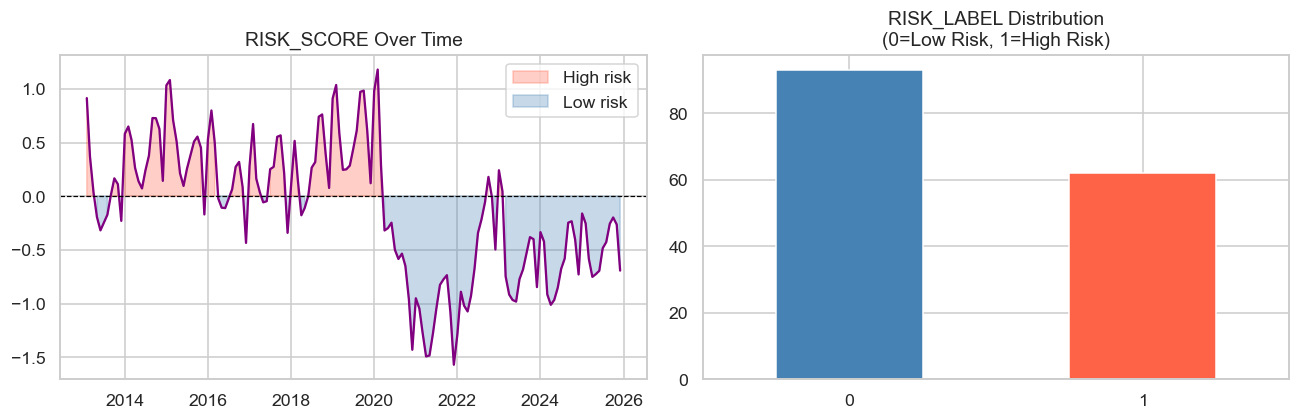

In [17]:
# Remove rows without enough past history before defining targets.
df = df.dropna().reset_index(drop=True)

RISK_FEATURES = ['PRICE_DROPS', 'MEDIAN_DOM', 'MONTHS_OF_SUPPLY']
train_size = int(len(df) * 0.8)
training_reference = df.head(train_size)

# Regression target: composite risk score using training-period statistics.
risk_z = df[RISK_FEATURES].copy()
for col in RISK_FEATURES:
    mean = training_reference[col].mean()
    std = training_reference[col].std()
    risk_z[col] = (df[col] - mean) / std
df['RISK_SCORE'] = risk_z.mean(axis=1)

# Classification target: high risk means above the training-period median.
price_drop_median = training_reference['PRICE_DROPS'].median()
df['RISK_LABEL'] = (df['PRICE_DROPS'] > price_drop_median).astype(int)

print(df['RISK_SCORE'].describe())
print(df['RISK_LABEL'].value_counts())

# Quick visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df['PERIOD_BEGIN'], df['RISK_SCORE'], color='purple', linewidth=1.5)
axes[0].fill_between(df['PERIOD_BEGIN'], df['RISK_SCORE'],
                     where=df['RISK_SCORE'] > 0, color='tomato', alpha=0.3, label='High risk')
axes[0].fill_between(df['PERIOD_BEGIN'], df['RISK_SCORE'],
                     where=df['RISK_SCORE'] <= 0, color='steelblue', alpha=0.3, label='Low risk')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('RISK_SCORE Over Time')
axes[0].legend()

df['RISK_LABEL'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], rot=0)
axes[1].set_title('RISK_LABEL Distribution\n(0=Low Risk, 1=High Risk)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

---
## 6. Finalise & Save

### What are we doing in this cell?

Lag features create `NaN` values in the first few rows (because there's no history before the start of the dataset). We drop those rows now — we can't train a model on incomplete rows.

Then we save the full engineered dataset to a new CSV file.

In [18]:
print(f'Final shape: {df.shape}')

OUT_PATH= '../data/processed/chicago_housing_engineered.csv'
df.to_csv(OUT_PATH, index=False)
df.head(3)

Final shape: (155, 41)


,PERIOD_BEGIN,MEDIAN_SALE_PRICE,HOMES_SOLD,NEW_LISTINGS,INVENTORY,MONTHS_OF_SUPPLY,MEDIAN_DOM,PRICE_DROPS,MONTH,YEAR,...,INVENTORY_ROLL6,MONTHS_OF_SUPPLY_ROLL3,MONTHS_OF_SUPPLY_ROLL6,MEDIAN_DOM_ROLL3,MEDIAN_DOM_ROLL6,PRICE_DROPS_ROLL3,PRICE_DROPS_ROLL6,PRICE_DROPS_YOY,RISK_SCORE,RISK_LABEL
0,2013-02-01,139000.0,5150.0,9615.0,29834.0,5.8,74.0,0.193739,2,2013,...,33930.666667,5.0,5.066667,70.666667,67.666667,0.201795,0.235197,-11.480097,0.914440,0
1,2013-03-01,155000.0,6877.0,10864.0,29598.0,4.3,67.0,0.202142,3,2013,...,32499.833333,5.3,5.233333,72.666667,69.166667,0.194595,0.220236,-23.461827,0.368770,0
2,2013-04-01,173000.0,7931.0,12783.0,30195.0,3.8,50.0,0.223249,4,2013,...,31176.333333,5.2,5.000000,72.000000,69.833333,0.208715,0.211570,-24.855574,0.036273,1


In [19]:
conn = sqlite3.connect('../sql/housing.db')
df.to_sql('chicago_housing_engineered', conn, if_exists='replace', index=False)
conn.close()

---
## Summary — All Engineered Features

| Feature group | Columns created | Count |
|--------------|----------------|-------|
| Original | MEDIAN_SALE_PRICE, HOMES_SOLD, NEW_LISTINGS, INVENTORY, MONTHS_OF_SUPPLY, MEDIAN_DOM, PRICE_DROPS | 7 |
| Temporal | MONTH, YEAR | 2 |
| Lag (1 month) | `{col}_LAG_1` for each of 7 numerics | 7 |
| Lag (3 months) | `{col}_LAG_3` for each of 7 numerics | 7 |
| Rolling (3-month) | `{col}_ROLL3` for each of 7 numerics | 7 |
| Rolling (6-month) | `{col}_ROLL6` for each of 7 numerics | 7 |
| YoY change | PRICE_DROPS_YOY | 1 |
| **Targets** | RISK_SCORE (regression), RISK_LABEL (classification) | 2 |
| **Total** | | **40** |

**Next step →** Open `04_model_training.ipynb` to train regression and classification models.